# ЭТАП 2. ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

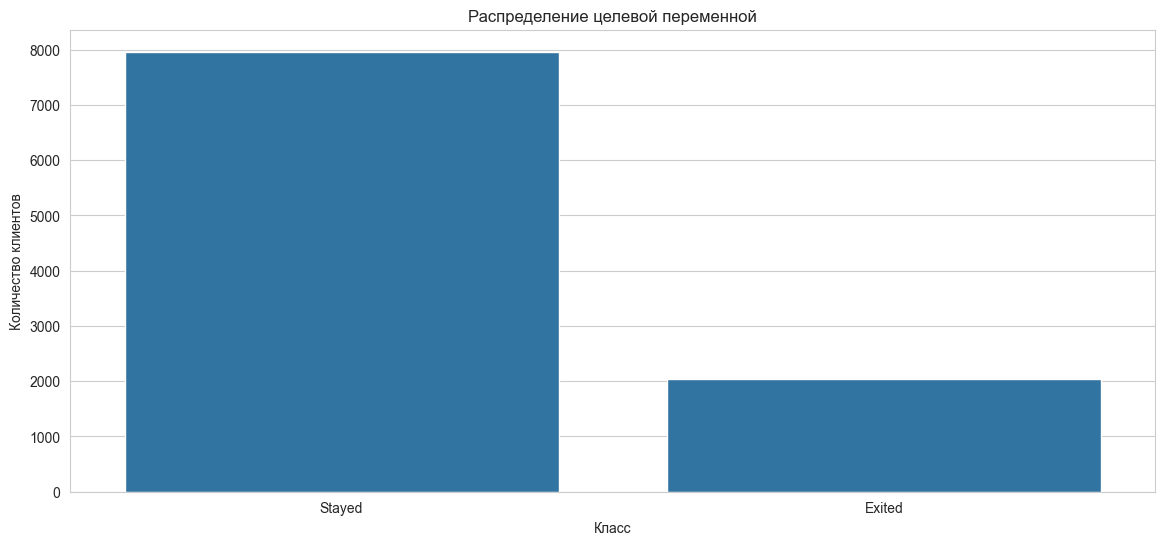

In [22]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv')



sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (14, 6)

plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='Exited')

plt.title('Распределение целевой переменной')

plt.xlabel('Класс')

plt.ylabel('Количество клиентов')

plt.xticks([0, 1], ['Stayed', 'Exited'])

plt.show()

# Процентное распределение классов

In [23]:
class_distribution = df['Exited'].value_counts(normalize=True) * 100

print('Процентное распределение классов:\n')

print(class_distribution)

Процентное распределение классов:

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


# АНАЛИЗ ВОЗРАСТА КЛИЕНТОВ

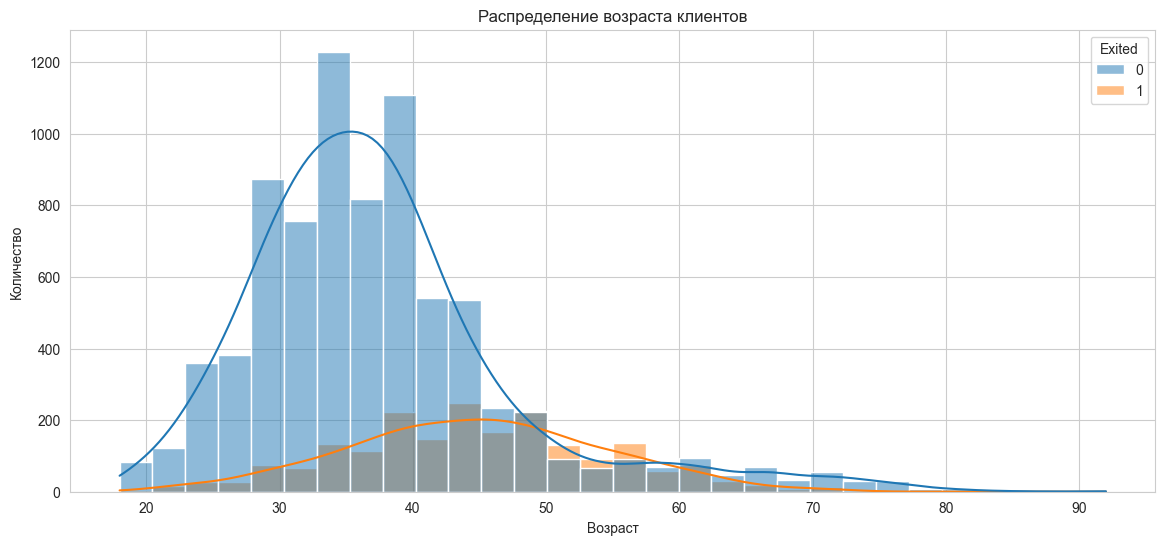

In [24]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=df,
    x='Age',
    hue='Exited',
    bins=30,
    kde=True
)

plt.title('Распределение возраста клиентов')

plt.xlabel('Возраст')

plt.ylabel('Количество')

plt.show()

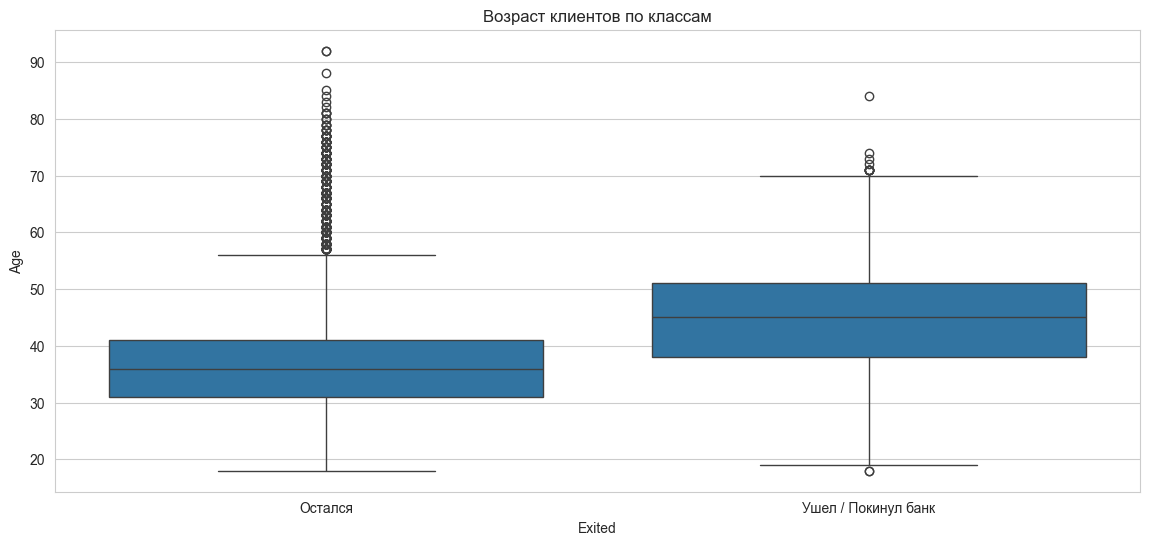

In [25]:
# Boxplot возраста

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="Age"
)

plt.title("Возраст клиентов по классам")

plt.xticks([0, 1], ["Остался", "Ушел / Покинул банк"])

plt.show()

# АНАЛИЗ КРЕДИТНОГО РЕЙТИНГА

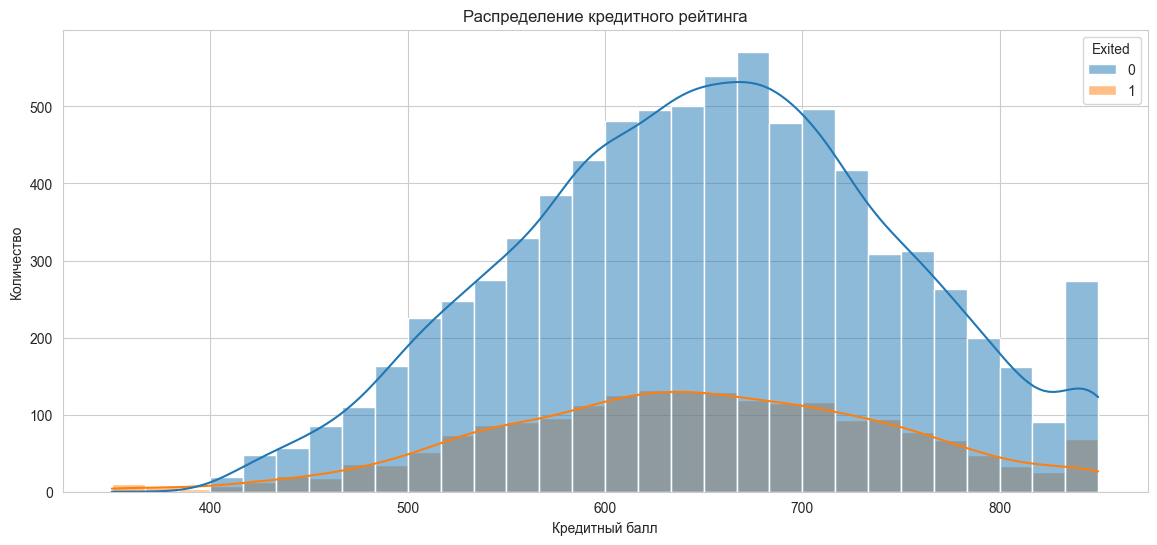

In [26]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=df,
    x='CreditScore',
    hue='Exited',
    bins=30,
    kde=True
)

plt.title('Распределение кредитного рейтинга')

plt.xlabel('Кредитный балл')

plt.ylabel('Количество')

plt.show()

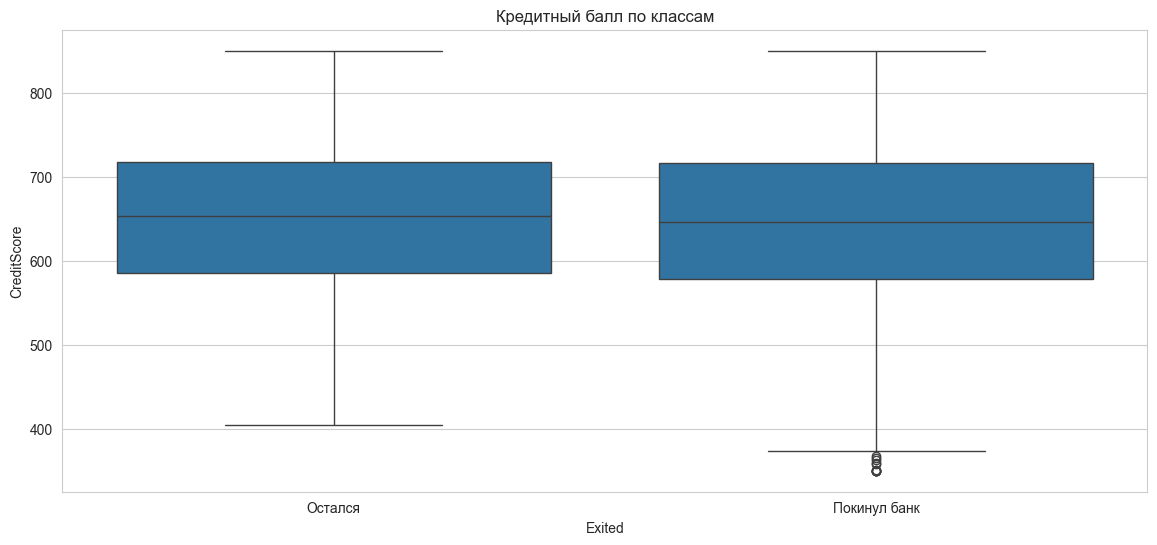

In [27]:
# Boxplot кредитного рейтинга

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="CreditScore"
)

plt.title("Кредитный балл по классам")

plt.xticks([0, 1], ["Остался", "Покинул банк"])

plt.show()

# АНАЛИЗ БАЛАНСА НА СЧЕТЕ

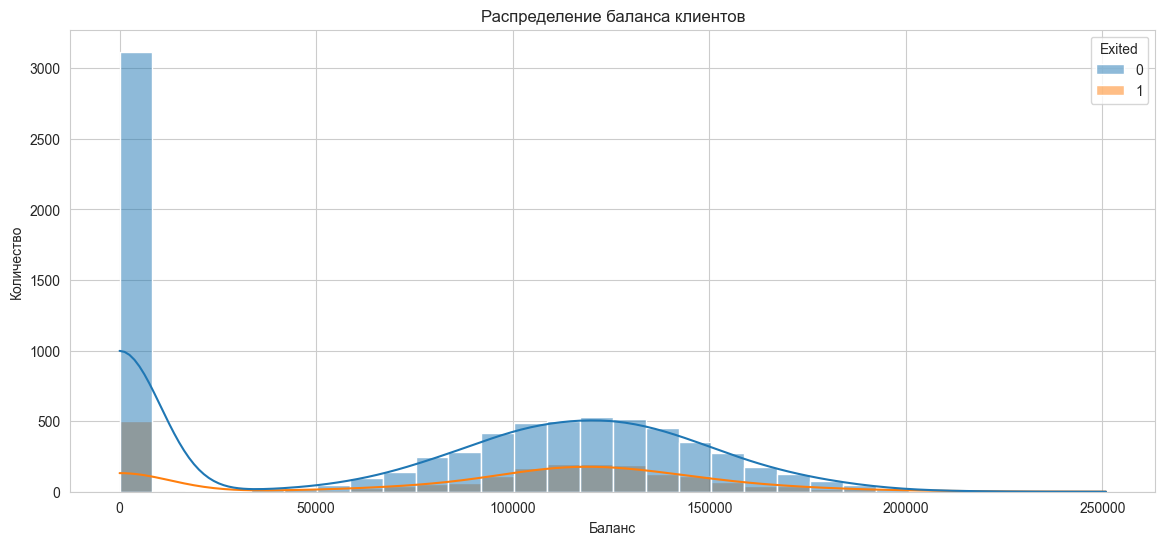

In [28]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=df,
    x='Balance',
    hue='Exited',
    bins=30,
    kde=True
)

plt.title('Распределение баланса клиентов')

plt.xlabel('Баланс')

plt.ylabel('Количество')

plt.show()

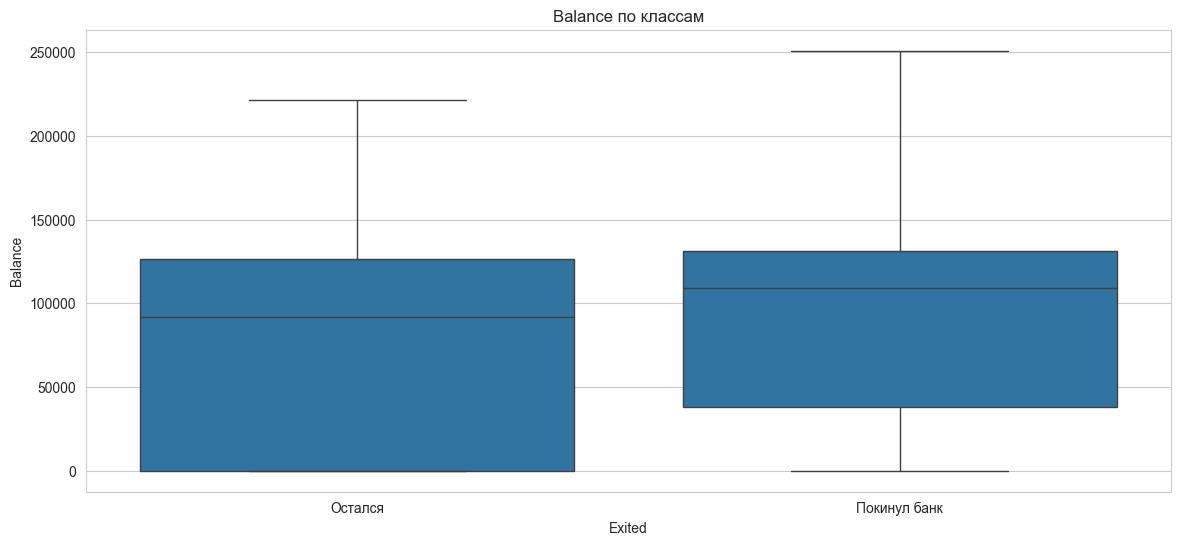

In [29]:
# Boxplot баланса

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="Balance"
)

plt.title("Balance по классам")

plt.xticks([0, 1], ["Остался", "Покинул банк"])

plt.show()

# КОЛИЧЕСТВО ИСПОЛЬЗУЕМЫХ ПРОДУКТОВ

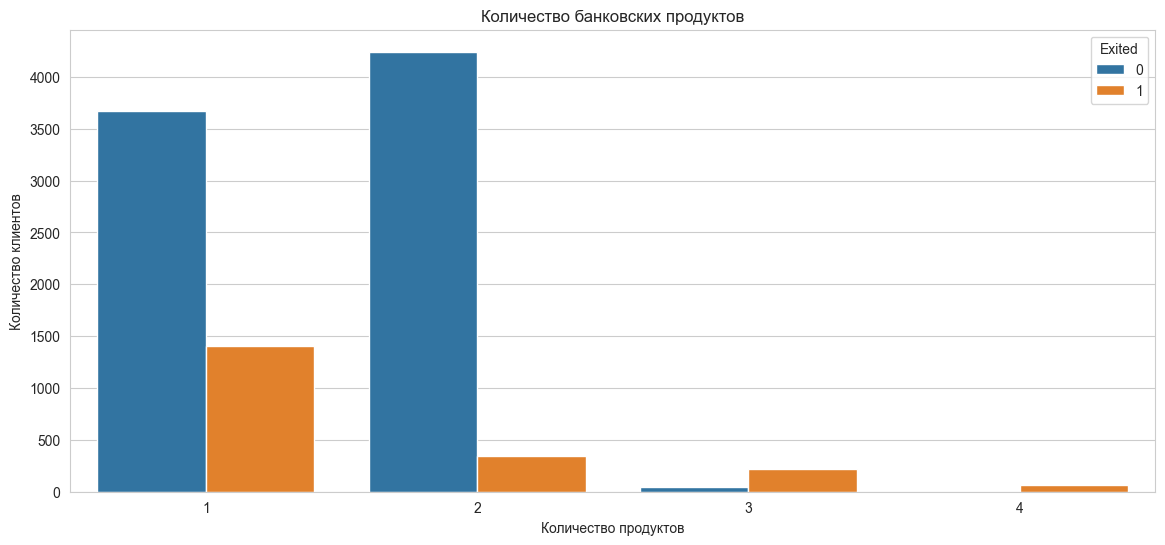

In [30]:
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='NumOfProducts',
    hue='Exited'
)

plt.title('Количество банковских продуктов')

plt.xlabel('Количество продуктов')

plt.ylabel('Количество клиентов')

plt.show()

# АКТИВНОСТЬ КЛИЕНТА

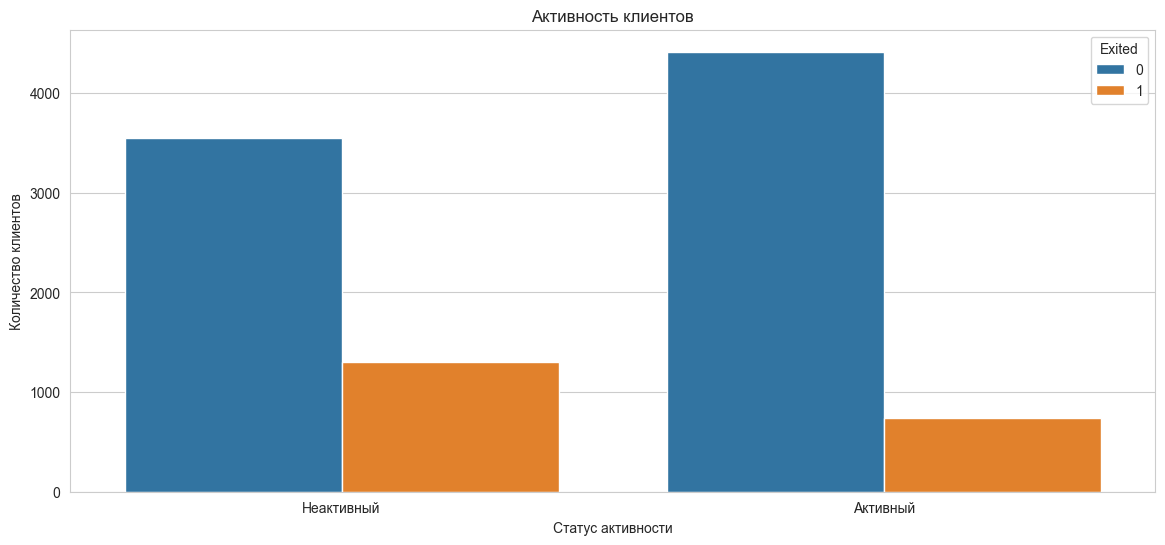

In [31]:
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='IsActiveMember',
    hue='Exited'
)

plt.title('Активность клиентов')

plt.xlabel('Статус активности')

plt.ylabel('Количество клиентов')

plt.xticks([0, 1], ['Неактивный', 'Активный'])

plt.show()

# ВЛИЯНИЕ СТРАНЫ НА ОТТОК

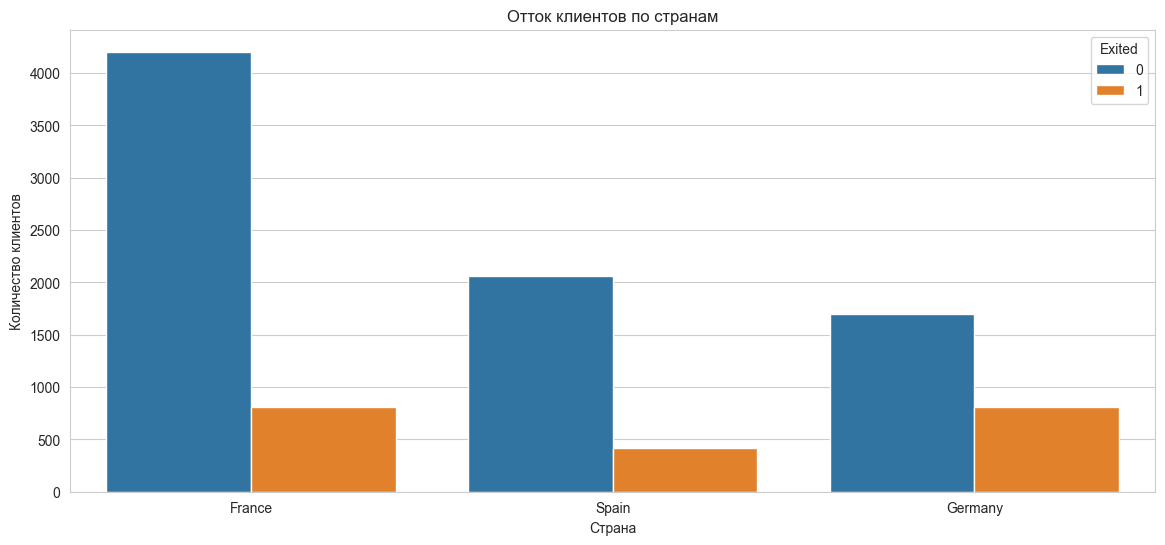

In [32]:
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='Geography',
    hue='Exited'
)

plt.title('Отток клиентов по странам')

plt.xlabel('Страна')

plt.ylabel('Количество клиентов')

plt.show()

# ВЛИЯНИЕ ПОЛА НА ОТТОК

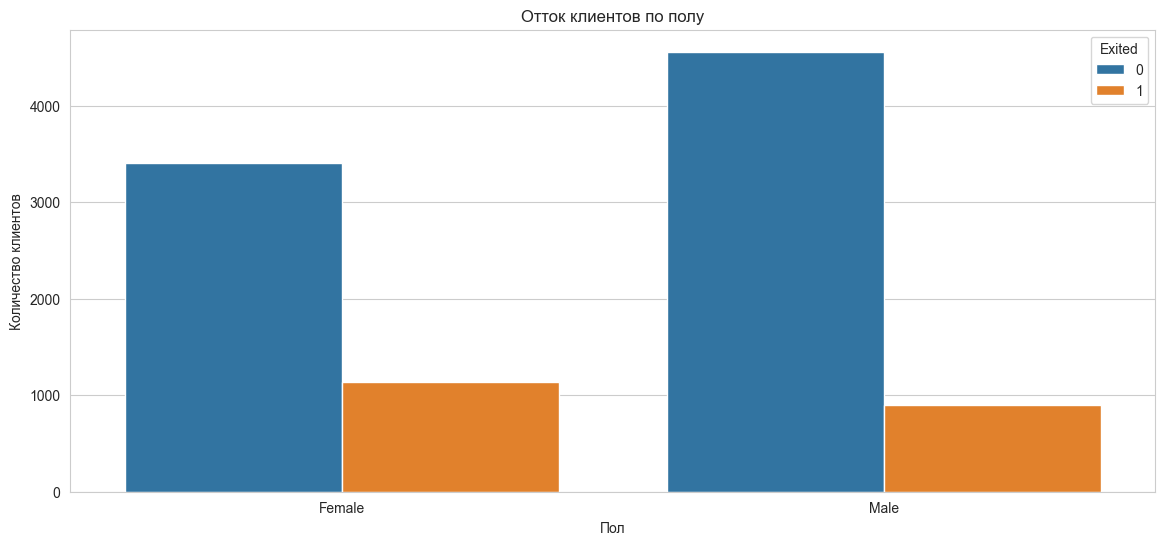

In [33]:
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='Gender',
    hue='Exited'
)

plt.title('Отток клиентов по полу')

plt.xlabel('Пол')

plt.ylabel('Количество клиентов')

plt.show()


# HEATMAP КОРРЕЛЯЦИИ

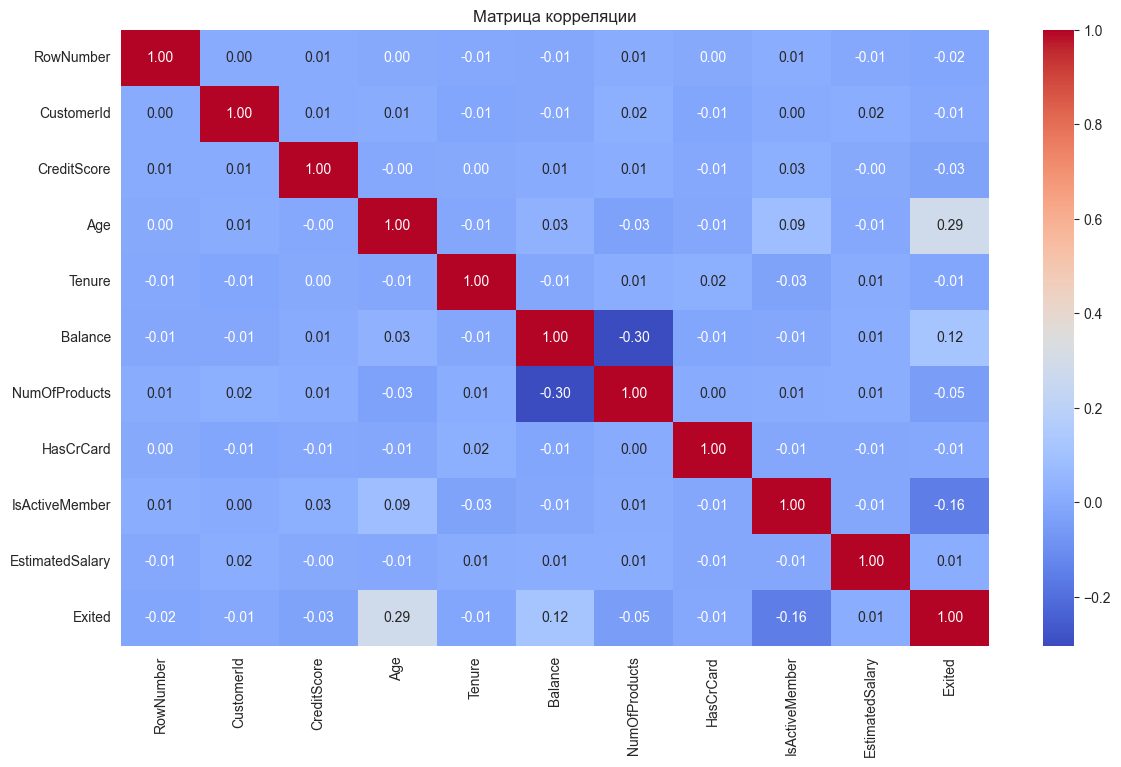

In [34]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Матрица корреляции')

plt.show()


# FEATURE DISTRIBUTION ПО КЛАССАМ

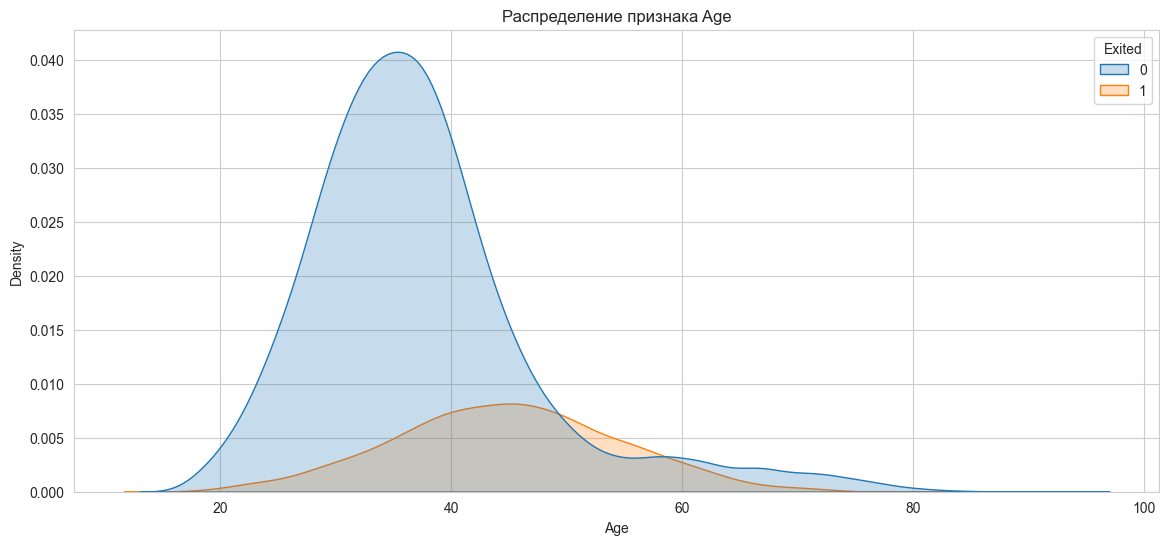

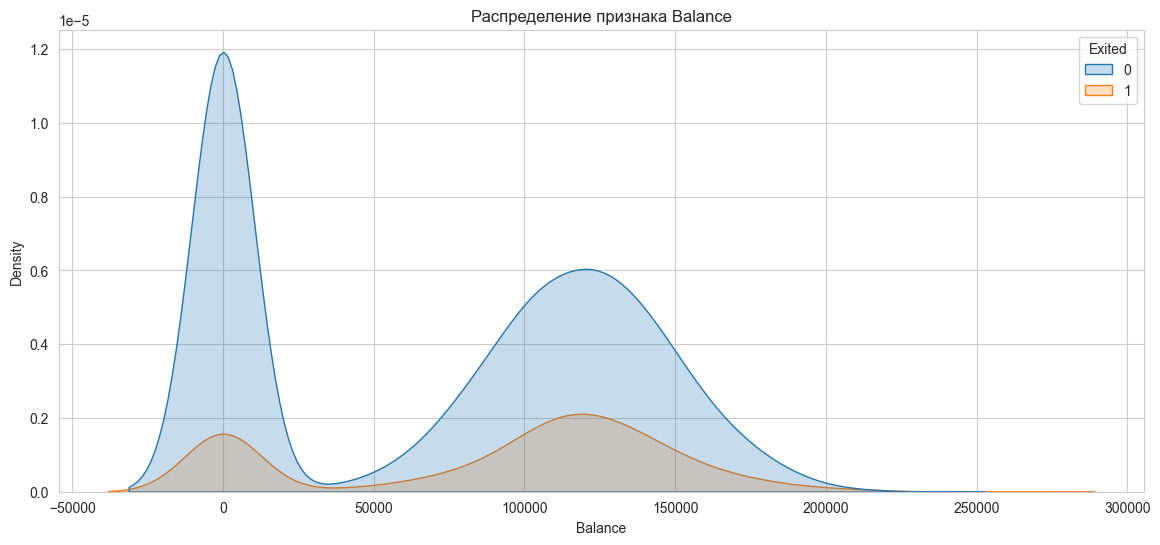

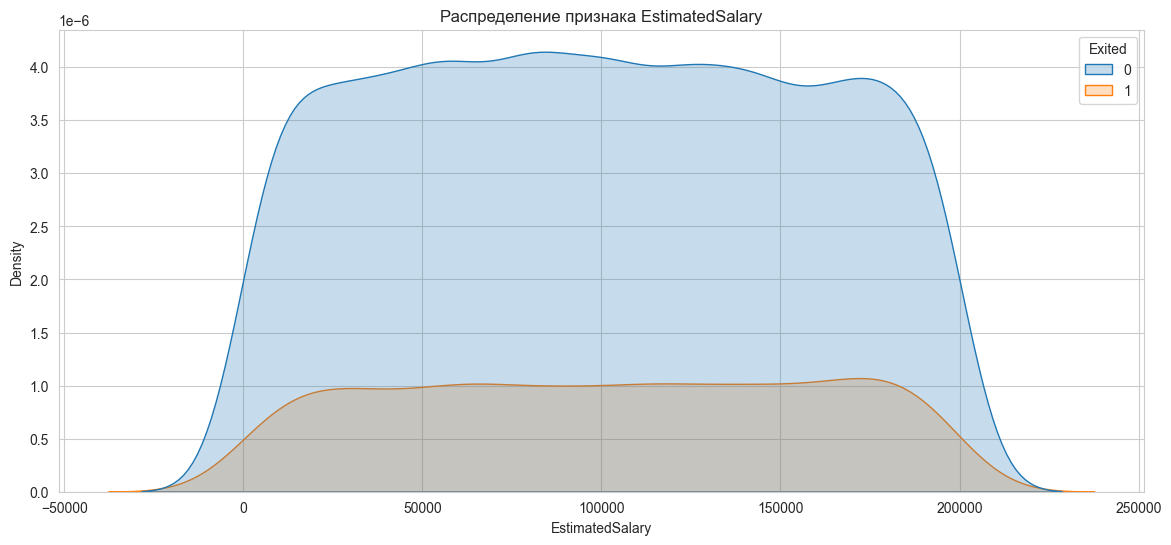

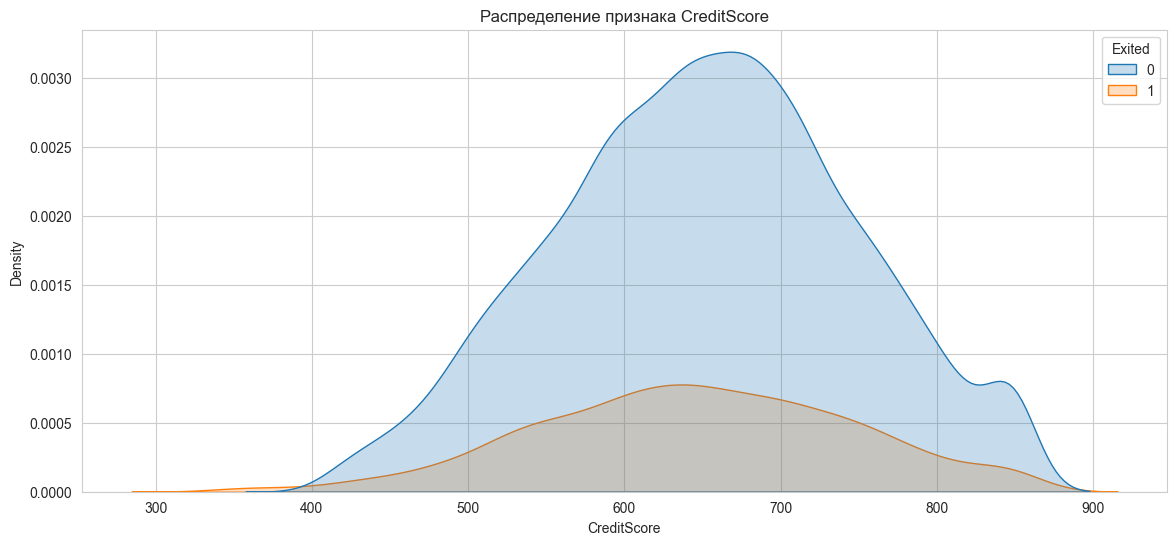

In [35]:
features = [
    'Age',
    'Balance',
    'EstimatedSalary',
    'CreditScore'
]

for feature in features:

    plt.figure(figsize=(14, 6))

    sns.kdeplot(
        data=df,
        x=feature,
        hue='Exited',
        fill=True
    )

    plt.title(f'Распределение признака {feature}')

    plt.show()


# АНАЛИЗ ВЫБРОСОВ

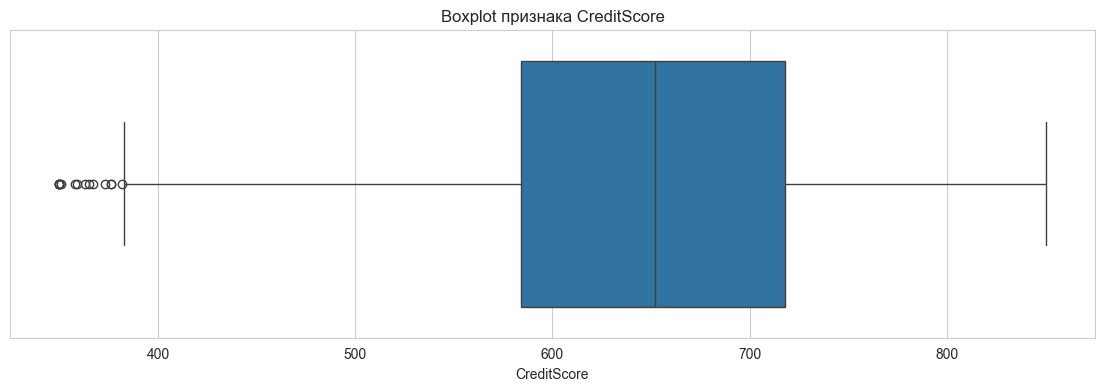

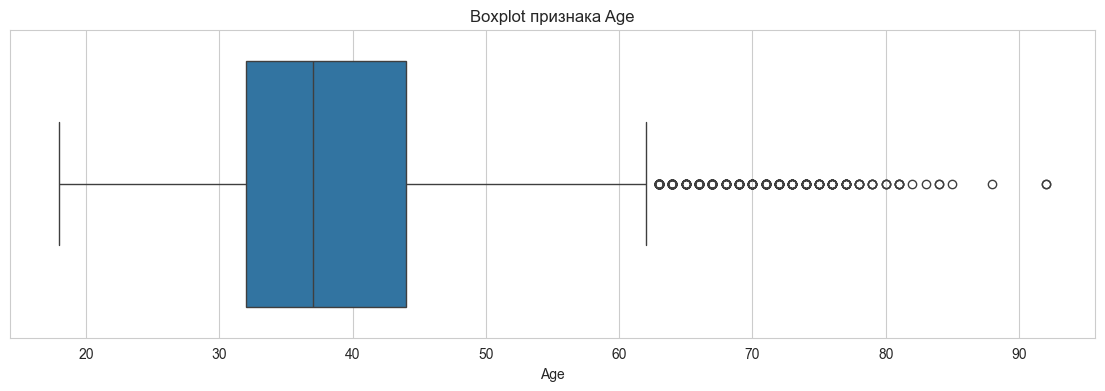

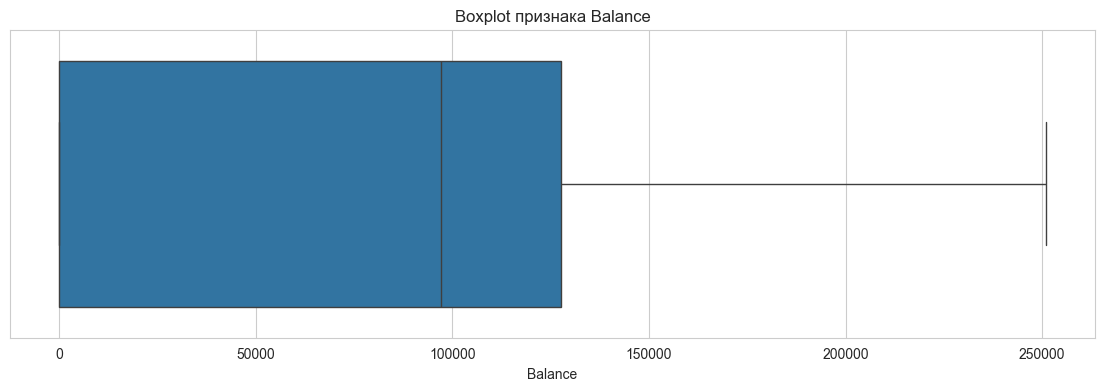

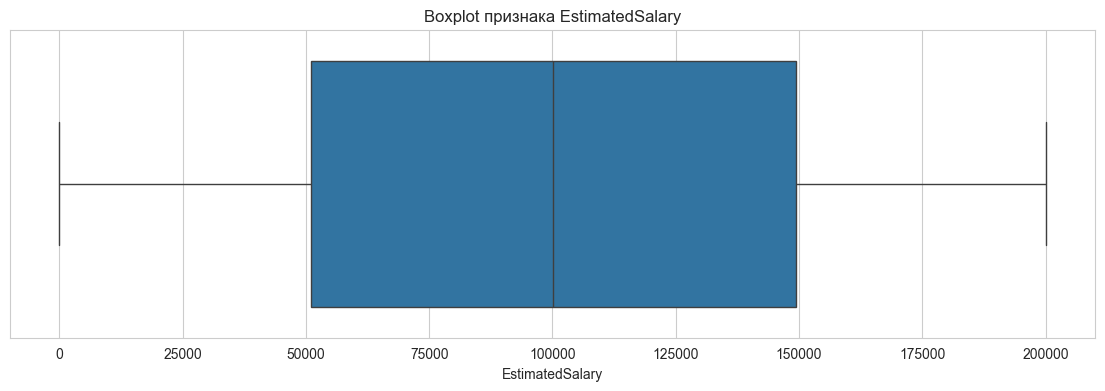

In [36]:
numeric_columns = [
    'CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary'
]

for col in numeric_columns:

    plt.figure(figsize=(14, 4))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f'Boxplot признака {col}')

    plt.show()


# ОСНОВНЫЕ ВЫВОДЫ EDA

In [37]:
print('''
Основные выводы:

1. Датасет несбалансирован:
   клиентов, которые остаются, больше.

2. Возраст влияет на вероятность ухода:
   более взрослые клиенты чаще уходят.

3. Высокий баланс счета может быть связан с оттоком.

4. Неактивные клиенты чаще покидают банк.

5. Количество банковских продуктов влияет на отток.

6. В некоторых странах наблюдается повышенный уровень ухода клиентов.

7. Некоторые признаки имеют выбросы,
   которые могут влиять на обучение модели.
''')


Основные выводы:

1. Датасет несбалансирован:
   клиентов, которые остаются, больше.

2. Возраст влияет на вероятность ухода:
   более взрослые клиенты чаще уходят.

3. Высокий баланс счета может быть связан с оттоком.

4. Неактивные клиенты чаще покидают банк.

5. Количество банковских продуктов влияет на отток.

6. В некоторых странах наблюдается повышенный уровень ухода клиентов.

7. Некоторые признаки имеют выбросы,
   которые могут влиять на обучение модели.

